# GloGEM individual-glacier NetCDF output check

Inspect and plot the **individual-glacier** GlacierMIP4 NetCDF files (`indiv` in the name),
and cross-check them against the `.dat` output (Section 5).

1. Set the file paths in the config cell.
2. Choose a glacier (by integer index or RGIId).
3. Run all cells.

> For runs reaching 2300, install `nc-time-axis` so matplotlib can plot cftime dates.

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Select files and glacier

In [8]:
# Data root (relative to this notebook's folder, output_checks/)
BASE = Path(r'C:\Users\alexandra\Documents\PhD\GloGEM_Hackathon_v3\GloGEM\output_checks\CentralEurope')

# Individual-glacier NetCDF files (full projection)  (EDIT if needed)
NETCDF_DIR     = BASE / 'files' / 'files_netcdf' / 'full'
ANNUAL_FILE    = NETCDF_DIR / 'GloGEM_rgi14_Aletsch_Morteratschindiv_BCC-CSM2-MR_ssp126_annual.nc'
SUBANNUAL_FILE = NETCDF_DIR / 'GloGEM_rgi14_Aletsch_Morteratschindiv_BCC-CSM2-MR_ssp126_monthly.nc'

# Glacier selection: 'index' (integer position) or 'rgiid' (match RGIId string)
SELECT_BY     = 'index'
GLACIER_INDEX = 0
GLACIER_RGIID = '02596'

print('annual    :', ANNUAL_FILE, '->', ANNUAL_FILE.exists())
print('sub-annual:', SUBANNUAL_FILE, '->', SUBANNUAL_FILE.exists())



annual    : C:\Users\alexandra\Documents\PhD\GloGEM_Hackathon_v3\GloGEM\output_checks\CentralEurope\files\files_netcdf\full\GloGEM_rgi14_Aletsch_Morteratschindiv_BCC-CSM2-MR_ssp126_annual.nc -> True
sub-annual: C:\Users\alexandra\Documents\PhD\GloGEM_Hackathon_v3\GloGEM\output_checks\CentralEurope\files\files_netcdf\full\GloGEM_rgi14_Aletsch_Morteratschindiv_BCC-CSM2-MR_ssp126_monthly.nc -> True


## 2. Inspect dimensions and variables

In [9]:
ds_ann = xr.open_dataset(ANNUAL_FILE)
ds_sub = xr.open_dataset(SUBANNUAL_FILE)

def describe(ds, name):
    print('=' * 70)
    print(name)
    print('=' * 70)
    print('Global attributes:')
    for k, v in ds.attrs.items():
        print('   {}: {}'.format(k, v))
    print('Dimensions:')
    for d, n in ds.sizes.items():
        print('   {}: {}'.format(d, n))
    print('Variables:')
    for vname in ds.variables:
        var = ds[vname]
        units = str(var.attrs.get('units', '-'))
        longn = var.attrs.get('long_name', '')
        cm = var.attrs.get('cell_methods', '')
        cm = '[' + cm + ']' if cm else ''
        print('   {:14s} dims={!s:24} units={:6} {} {}'.format(vname, tuple(var.dims), units, longn, cm))
    print()

describe(ds_ann, 'ANNUAL FILE')
describe(ds_sub, 'SUB-ANNUAL FILE')

ANNUAL FILE
Global attributes:
   Conventions: CF-1.8
   model: GloGEM
   institution: ETH, VAW
   rgi_region: 14
   catchment: Aletsch_Morteratsch
   forcing: BCC-CSM2-MR_ssp126
   gcm: BCC-CSM2-MR
   scenario: ssp126
   gcm_data: cmip6
   period: 1940-2100
   creation_date: Tue Jun 16 16:01:52 2026
Dimensions:
   glacier: 2
   time: 161
Variables:
   RGIId          dims=('glacier',)             units=-      Randolph Glacier Inventory ID 
   area           dims=('time', 'glacier')      units=m2     Glacier area [time: point]
   mass           dims=('time', 'glacier')      units=kg     Glacier mass [time: point]
   mass_bsl       dims=('time', 'glacier')      units=kg     Glacier mass below sea level [time: point]
   frontal_abl    dims=('time', 'glacier')      units=kg     Total annual frontal ablation [time: sum]
   ELA            dims=('time', 'glacier')      units=m      Altitude of the annual equilibrium line [time: maximum]
   AAR            dims=('time', 'glacier')      units=% 

## 3. Resolve the selected glacier

In [10]:
rgiids = np.array([str(x) for x in ds_ann['RGIId'].values])
print('{} glaciers in file'.format(len(rgiids)))
print('First RGIIds:', rgiids[:10])

if SELECT_BY == 'rgiid':
    matches = np.where(rgiids == GLACIER_RGIID)[0]
    if len(matches) == 0:
        raise ValueError('RGIId {!r} not found in file'.format(GLACIER_RGIID))
    g = int(matches[0])
else:
    g = int(GLACIER_INDEX)

gid = rgiids[g]
print('Selected glacier index {} -> RGIId {}'.format(g, gid))

2 glaciers in file
First RGIIds: ['02596' '02216']
Selected glacier index 0 -> RGIId 02596


## 4. Plot selected variables for this glacier

Edit the `panels` list to add/remove variables. Missing variables are skipped automatically.

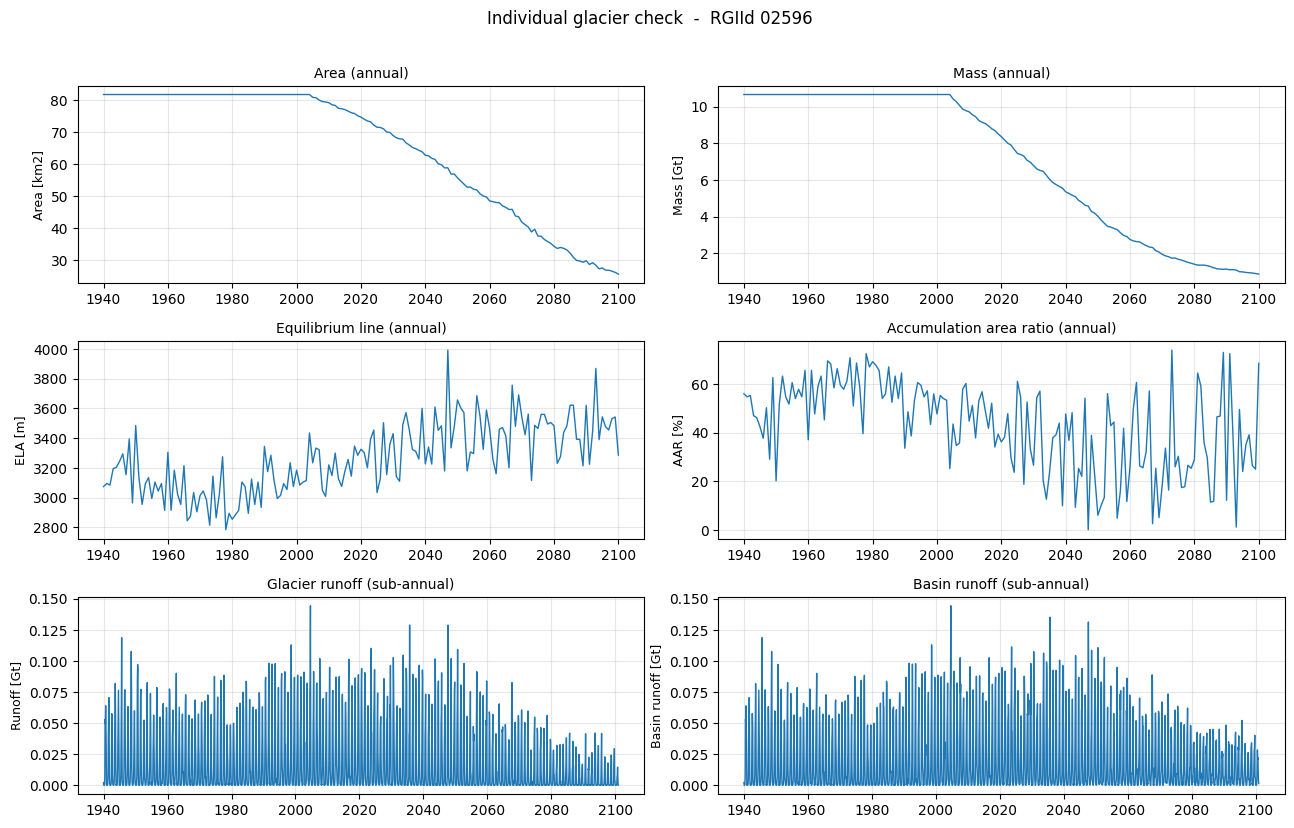

In [11]:
GT  = 1e-12   # kg  -> Gt
KM2 = 1e-6    # m2  -> km2

def glacier_dim(da):
    return [d for d in da.dims if d != 'time'][0]

# (dataset, variable, scale, ylabel, title)
panels = [
    (ds_ann, 'area',         KM2, 'Area [km2]',        'Area (annual)'),
    (ds_ann, 'mass',         GT,  'Mass [Gt]',         'Mass (annual)'),
    (ds_ann, 'ELA',          1.0, 'ELA [m]',           'Equilibrium line (annual)'),
    (ds_ann, 'AAR',          1.0, 'AAR [%]',           'Accumulation area ratio (annual)'),
    (ds_sub, 'runoff_glac',  GT,  'Runoff [Gt]',       'Glacier runoff (sub-annual)'),
    (ds_sub, 'runoff_basin', GT,  'Basin runoff [Gt]', 'Basin runoff (sub-annual)'),
]
panels = [p for p in panels if p[1] in p[0].variables]

ncol = 2
nrow = int(np.ceil(len(panels) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.8 * nrow), squeeze=False)
axes = axes.ravel()

for ax, (ds, var, scale, ylabel, title) in zip(axes, panels):
    gdim = glacier_dim(ds[var])
    data = ds[var].isel({gdim: g}) * scale
    ax.plot(ds['time'].values, data.values, lw=1.0)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(alpha=0.3)

for ax in axes[len(panels):]:
    ax.set_visible(False)

fig.suptitle('Individual glacier check  -  RGIId {}'.format(gid), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 5. Compare NetCDF vs .dat (this glacier)

The `.dat` files hold the raw specific values; convert them to SI and overlay on the
NetCDF for the selected glacier. They should coincide (`max rel.diff` near 0).

`precip` (different area basis) and `temp` (no `.dat` equivalent) are omitted.

Matching .dat glacier key: 02596


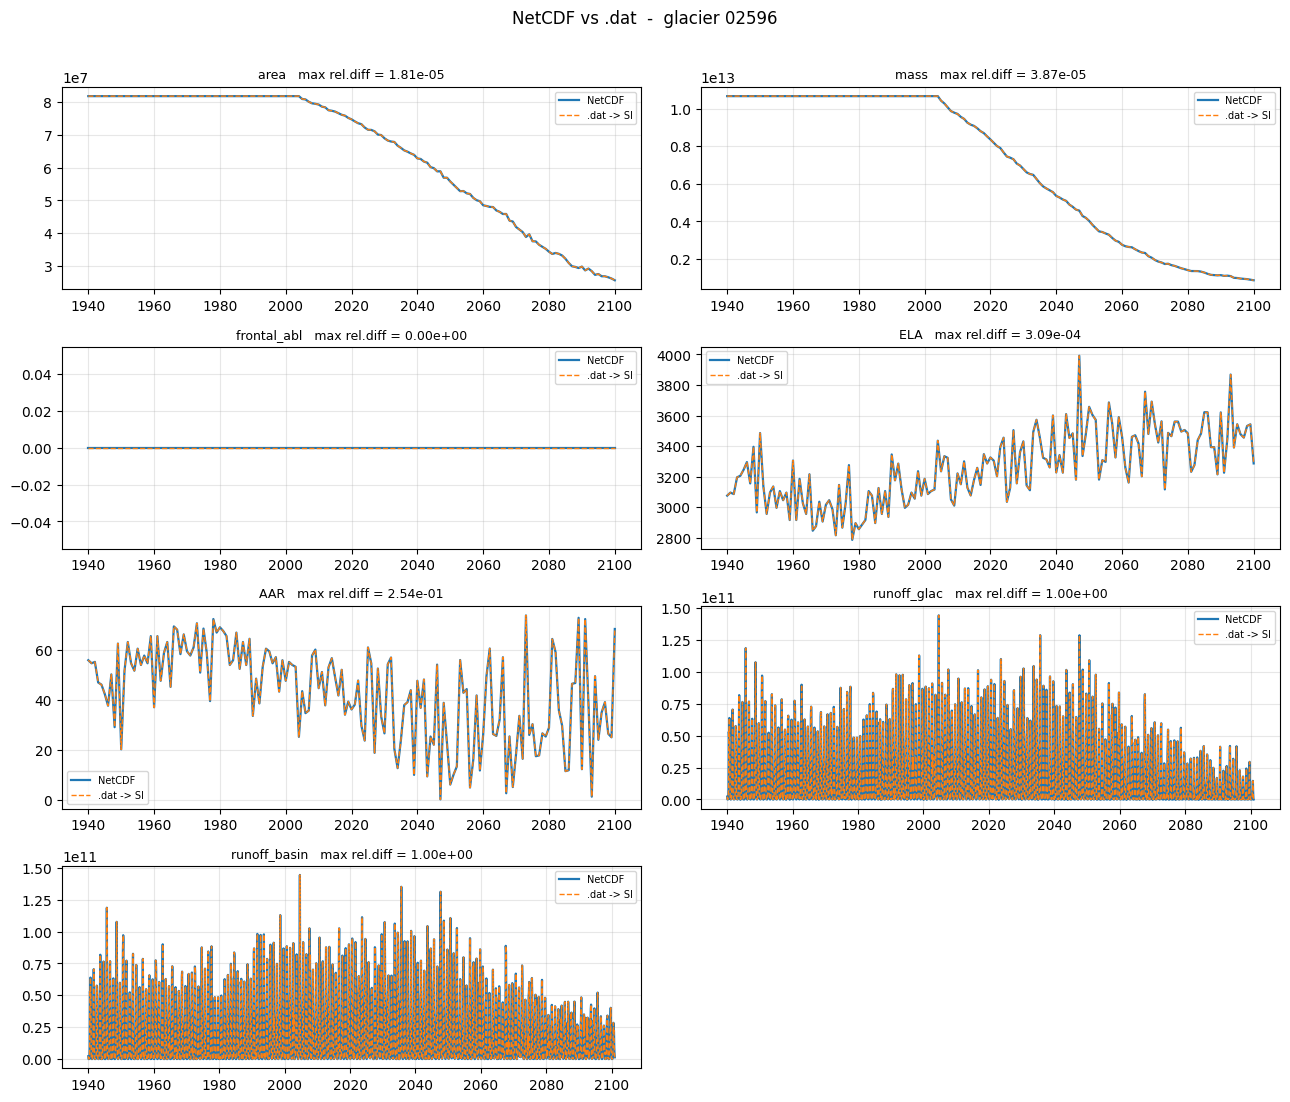

In [14]:
# ---- .dat location (EDIT if needed) ----
DAT_DIR    = BASE / 'files' / 'files_original' / 'BCC-CSM2-MR' / 'ssp126'
DAT_PREFIX = 'centraleurope_'
DAT_SUFFIX = '_r1_Aletsch_Morteratsch.dat'

def dat_file(var):
    return DAT_DIR / (DAT_PREFIX + var + DAT_SUFFIX)

def read_dat_rows(path):
    # {glacier_id: values}; first line skipped (monthly files carry a mislabeled header)
    rows = {}
    with open(path) as f:
        f.readline()
        for line in f:
            p = line.split()
            if p:
                rows[p[0]] = np.array(p[1:], dtype=float)
    return rows

def dat_key(rgiid):
    s = str(rgiid)
    return s.split('.')[-1] if '.' in s else s   # handles future RGI70-11.02596 ids

def reldiff(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if not np.any(m):
        return np.nan
    denom = np.maximum(np.abs(a[m]), np.abs(b[m]))
    nz = denom > 0
    if not np.any(nz):
        return 0.0
    return np.max(np.abs(a[m][nz] - b[m][nz]) / denom[nz])

key      = dat_key(gid)
area_km2 = read_dat_rows(dat_file('Area'))[key]   # annual area [km2]
area_mon = np.repeat(area_km2, 12)                # broadcast across months
area0    = area_km2[0]                            # area_cat for runoff_basin
print('Matching .dat glacier key:', key)

# (netcdf_var, dataset, dat_var, converter dat -> SI)
comparisons = [
    ('area',         ds_ann, 'Area',             lambda d: d * 1e6),
    ('mass',         ds_ann, 'Volume',           lambda d: d * 900e9),
    ('frontal_abl',  ds_ann, 'Frontal_ablation', lambda d: d * area_km2 * 1e9),
    ('ELA',          ds_ann, 'ELA',              lambda d: d),
    ('AAR',          ds_ann, 'AAR',              lambda d: d),
    ('acc',          ds_sub, 'Accumulation_mon', lambda d: d * area_mon * 1e9),
    ('melt',         ds_sub, 'Melt_mon',         lambda d: d * area_mon * 1e9),
    ('refreeze',     ds_sub, 'Refreezing_mon',   lambda d: d * area_mon * 1e9),
    ('runoff_glac',  ds_sub, 'Discharge_gl',     lambda d: d * area_mon * 1e9),
    ('runoff_basin', ds_sub, 'Discharge',        lambda d: d * area0 * 1e9),
]
comparisons = [c for c in comparisons if c[0] in c[1].variables and dat_file(c[2]).exists()]

ncol = 2
nrow = int(np.ceil(len(comparisons) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.8 * nrow), squeeze=False)
axes = axes.ravel()
for ax, (ncv, ds, datv, conv) in zip(axes, comparisons):
    t  = ds['time'].values
    nc = np.asarray(ds[ncv].isel({glacier_dim(ds[ncv]): g}).values, float)
    si = conv(read_dat_rows(dat_file(datv))[key])
    n  = min(len(t), len(nc), len(si))
    ax.plot(t[:n], nc[:n], lw=1.6, label='NetCDF')
    ax.plot(t[:n], si[:n], lw=1.0, ls='--', label='.dat -> SI')
    ax.set_title('{}   max rel.diff = {:.2e}'.format(ncv, reldiff(nc[:n], si[:n])), fontsize=9)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
for ax in axes[len(comparisons):]:
    ax.set_visible(False)
fig.suptitle('NetCDF vs .dat  -  glacier {}'.format(gid), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### How to read this figure

Each panel overlays the **NetCDF** value (solid) against the **`.dat` value converted to SI units** (dashed). They should lie on top of each other — and here they do. The `max rel.diff` in each title is `max(|a−b| / max(|a|,|b|))` over all time steps.

**Why nothing reaches exactly 0:** the `.dat` files are rounded text (fixed decimals per variable), while the NetCDF keeps full float32. The residual differences therefore sit at the `.dat`'s rounding precision — they are a property of the text files, not a NetCDF error.

**Bottom line:** the NetCDF output is consistent with the `.dat` output. The high `max rel.diff` values for `runoff_*` and `AAR` are artifacts of the relative metric near zero combined with `.dat` text rounding, confirmed by the overlapping curves — not a problem with the NetCDF.
